# Multi-Scale Registration of Mammograms and Cross-Sequence IDC MR Slices

**Goal:** Register a moving image to a fixed image with a transparent coarse-to-fine optimizer. The original mammogram example still works, and this version also supports the cross-sequence IDC example requested for the assignment: same-patient T1-weighted and T2-FLAIR axial MR slices.

**Method (didactic version):**
1. Optionally mirror the moving image for left/right mammograms.
2. Optionally convert both images to gradient-magnitude images before registration.
3. Build a Gaussian image pyramid (factor 2 per level).
4. Estimate a transform at the coarsest level and refine it level by level.
5. Choose **rigid** or **affine** registration via a single switch.
6. Choose **MSE** or **normalized cross-correlation (NCC)** via a single switch.

The important evaluation change is that every pyramid level is also evaluated on the finest/original resolution. That makes the plotted values comparable across levels, instead of mixing scores measured on different downsampled images.

For different modalities or sequences, MSE/SSD is usually a poor objective because gray values do not have the same meaning. NCC is more robust to global brightness and contrast changes, and NCC on gradient-magnitude images focuses the optimizer on shared anatomical edges.


## 1. Imports and configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, affine_transform
from scipy.optimize import minimize
from pathlib import Path

# --- User settings -----------------------------------------------------------
MODE = 'affine'          # 'rigid' (3 params) or 'affine' (6 params)
METRIC = 'ncc'           # 'mse' or 'ncc'
PREPROCESS = 'gradient'  # 'none' or 'gradient'
N_LEVELS = 6             # 6 levels => coarsest is downsampled by about 2^5 = 32
MIRROR_MOVING = False    # True for left/right mammograms, False for the IDC MR pair
PIXEL_SIZE_MM = 0.9765625  # used only for reporting translations in approximate mm

# The local IDC example contains same-patient T1 and T2-FLAIR axial slices from
# UPENN-GBM-00204. If the files are absent (for example on Kaggle), the notebook
# falls back to the original MIAS mammogram pair.
IDC_DIR = Path('data/idc_upenn_gbm_00204_png')
IDC_FIXED_PATH = IDC_DIR / 'upenn_gbm_00204_t1_axial.png'
IDC_MOVING_PATH = IDC_DIR / 'upenn_gbm_00204_t2_flair_axial.png'

if IDC_FIXED_PATH.exists() and IDC_MOVING_PATH.exists():
    FIXED_PATH = IDC_FIXED_PATH
    MOVING_PATH = IDC_MOVING_PATH
    FIXED_LABEL = 'IDC UPENN-GBM-00204 T1 axial'
    MOVING_LABEL = 'IDC UPENN-GBM-00204 T2-FLAIR axial'
else:
    MODE = 'rigid'
    METRIC = 'mse'
    PREPROCESS = 'none'
    MIRROR_MOVING = True
    PIXEL_SIZE_MM = 0.1
    FIXED_PATH = Path('/kaggle/input/datasets/kmader/mias-mammography/all-mias/mdb015.pgm')
    MOVING_PATH = Path('/kaggle/input/datasets/kmader/mias-mammography/all-mias/mdb016.pgm')
    FIXED_LABEL = 'MIAS mdb015 right mammogram'
    MOVING_LABEL = 'MIAS mdb016 left mammogram'

rng = np.random.default_rng(0)
print(f'MODE={MODE}, METRIC={METRIC}, PREPROCESS={PREPROCESS}, MIRROR_MOVING={MIRROR_MOVING}')
print(f'fixed:  {FIXED_PATH}')
print(f'moving: {MOVING_PATH}')


MODE=affine, METRIC=ncc, PREPROCESS=gradient, MIRROR_MOVING=False
fixed:  data\idc_upenn_gbm_00204_png\upenn_gbm_00204_t1_axial.png
moving: data\idc_upenn_gbm_00204_png\upenn_gbm_00204_t2_flair_axial.png


## 2. Loading images

We accept PGM/PNG/JPG via PIL/Pillow and DICOM via `pydicom` if available. The image is converted to a float array in `[0, 1]`. The IDC PNGs are already square 1024 x 1024 slices, but the registration code below no longer requires equal image sizes.


In [2]:
def normalize01(img):
    img = img.astype(np.float32, copy=False)
    img = img - np.nanmin(img)
    max_value = np.nanmax(img)
    if max_value > 0:
        img = img / max_value
    return img

def load_image(path):
    """Load a 2D grayscale image as a float array normalized to [0, 1]."""
    path = Path(path)
    if path.suffix.lower() in {'.dcm', '.dicom'}:
        import pydicom
        img = pydicom.dcmread(path).pixel_array.astype(np.float32)
    else:
        from PIL import Image
        pil_img = Image.open(path)
        if pil_img.mode not in ('L', 'I', 'F'):
            pil_img = pil_img.convert('L')
        img = np.asarray(pil_img).astype(np.float32)
    return normalize01(img)

fixed = load_image(FIXED_PATH)
moving = load_image(MOVING_PATH)

if MIRROR_MOVING:
    moving = np.ascontiguousarray(moving[:, ::-1])

print(f'{FIXED_LABEL}:  shape={fixed.shape}, dtype={fixed.dtype}')
print(f'{MOVING_LABEL}: shape={moving.shape}, dtype={moving.dtype}, mirrored={MIRROR_MOVING}')


IDC UPENN-GBM-00204 T1 axial:  shape=(1024, 1024), dtype=float32
IDC UPENN-GBM-00204 T2-FLAIR axial: shape=(1024, 1024), dtype=float32, mirrored=False


## 3. Registration image pyramid

The display images remain the original normalized intensities. The registration images can optionally be gradient magnitudes. For T1-vs-FLAIR, gradient preprocessing is useful because edges and anatomical boundaries are more comparable than raw gray values.


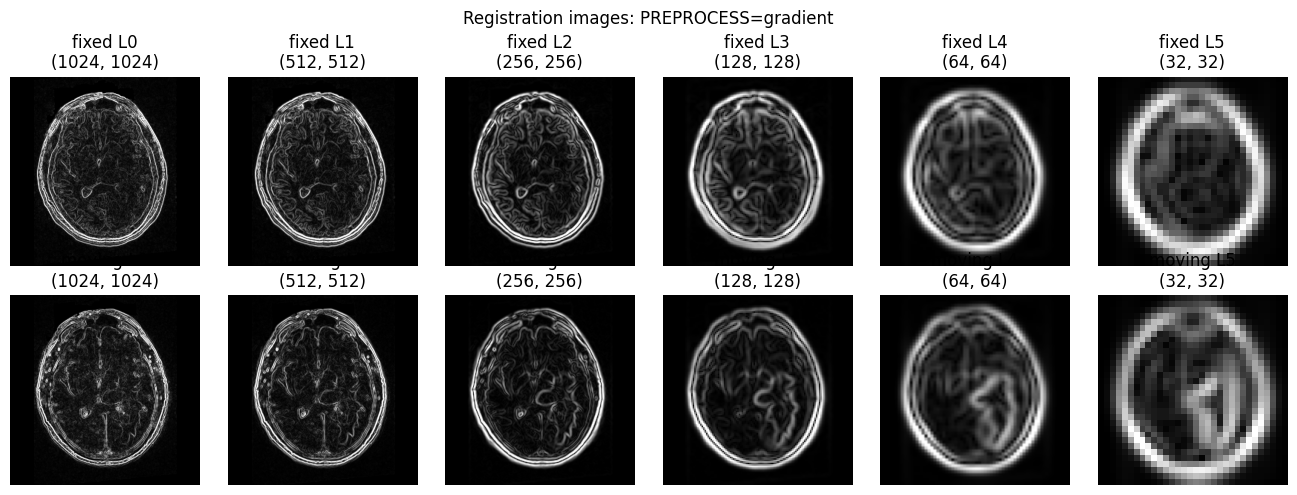

In [3]:
def robust_normalize01(img, low=1.0, high=99.0):
    """Normalize with percentiles so a few strong edges do not dominate."""
    lo, hi = np.percentile(img, [low, high])
    if hi <= lo:
        return normalize01(img)
    return np.clip((img - lo) / (hi - lo), 0.0, 1.0).astype(np.float32)

def gradient_magnitude(img, sigma=1.0):
    """Gaussian-smoothed gradient magnitude, normalized to [0, 1]."""
    smoothed = gaussian_filter(img, sigma=sigma)
    gy, gx = np.gradient(smoothed)
    return robust_normalize01(np.hypot(gx, gy))

def preprocess_level(img, preprocess):
    if preprocess == 'none':
        return img.astype(np.float32, copy=False)
    if preprocess == 'gradient':
        return gradient_magnitude(img, sigma=1.0)
    raise ValueError(f'unknown preprocessing mode {preprocess!r}')

def build_pyramid(img, n_levels):
    """Return [level_0, level_1, ...], where level_0 is full resolution."""
    pyr = [img.astype(np.float32, copy=False)]
    for _ in range(n_levels - 1):
        smoothed = gaussian_filter(pyr[-1], sigma=1.0)
        pyr.append(smoothed[::2, ::2])
    return pyr

def build_registration_pyramid(img, n_levels, preprocess):
    intensity_pyr = build_pyramid(img, n_levels)
    return [preprocess_level(level_img, preprocess) for level_img in intensity_pyr]

fixed_display_pyr = build_pyramid(fixed, N_LEVELS)
moving_display_pyr = build_pyramid(moving, N_LEVELS)
fixed_pyr = build_registration_pyramid(fixed, N_LEVELS, PREPROCESS)
moving_pyr = build_registration_pyramid(moving, N_LEVELS, PREPROCESS)

fig, axes = plt.subplots(2, N_LEVELS, figsize=(2.2 * N_LEVELS, 5))
for k in range(N_LEVELS):
    axes[0, k].imshow(fixed_pyr[k], cmap='gray')
    axes[0, k].set_title(f'fixed L{k}\n{fixed_pyr[k].shape}')
    axes[1, k].imshow(moving_pyr[k], cmap='gray')
    axes[1, k].set_title(f'moving L{k}\n{moving_pyr[k].shape}')
    for ax in (axes[0, k], axes[1, k]):
        ax.axis('off')
plt.suptitle(f'Registration images: PREPROCESS={PREPROCESS}')
plt.tight_layout(); plt.show()


## 4. Parameterizing the transform

Transforms are parameterized around image centers. For unequal image sizes, identity maps the center of the fixed output frame to the center of the moving input frame:

`moving_coord = M @ (fixed_coord - fixed_center) + moving_center + translation`

`scipy.ndimage.affine_transform` needs this inverse mapping from output coordinates to input coordinates, so the code builds `M` and `offset` explicitly.


In [4]:
def params_to_matrix(params, mode, fixed_shape, moving_shape):
    """Convert parameters to (M, offset) for scipy.ndimage.affine_transform."""
    fixed_center = (np.array(fixed_shape, dtype=np.float64) - 1.0) / 2.0
    moving_center = (np.array(moving_shape, dtype=np.float64) - 1.0) / 2.0
    if mode == 'rigid':
        tx, ty, theta = params
        M = np.array([[ np.cos(theta), -np.sin(theta)],
                      [ np.sin(theta),  np.cos(theta)]], dtype=np.float64)
    elif mode == 'affine':
        a11, a12, a21, a22, tx, ty = params
        M = np.eye(2, dtype=np.float64) + np.array([[a11, a12], [a21, a22]], dtype=np.float64)
    else:
        raise ValueError(f'unknown mode {mode!r}')
    t = np.array([ty, tx], dtype=np.float64)
    offset = moving_center + t - M @ fixed_center
    return M, offset

def warp(moving_img, params, mode, output_shape, order=1, cval=0.0):
    """Warp moving_img into an output array shaped like the fixed image."""
    M, offset = params_to_matrix(params, mode, output_shape, moving_img.shape)
    return affine_transform(
        moving_img, M, offset=offset, output_shape=tuple(output_shape), order=order,
        mode='constant', cval=cval, prefilter=False
    )

def valid_overlap_mask(moving_img, params, mode, output_shape):
    mask_img = np.ones_like(moving_img, dtype=np.float32)
    return warp(mask_img, params, mode, output_shape, order=0, cval=0.0) > 0.5

def initial_params(mode):
    return np.zeros(3 if mode == 'rigid' else 6, dtype=np.float64)


## 5. Scaling parameters between pyramid levels

Rotations and affine matrix entries are dimensionless. Translations are measured in pixels, so `tx` and `ty` must be scaled when moving between pyramid levels. The same scaling is used to re-express any level's parameters at level 0 for finest-resolution evaluation.


In [5]:
def scale_params(params, mode, y_factor=1.0, x_factor=1.0):
    p = params.copy()
    if mode == 'rigid':
        p[0] *= x_factor  # tx
        p[1] *= y_factor  # ty
    else:
        p[4] *= x_factor  # tx
        p[5] *= y_factor  # ty
    return p

def params_at_level0(params, mode, level, fixed_pyr):
    y_factor = fixed_pyr[0].shape[0] / fixed_pyr[level].shape[0]
    x_factor = fixed_pyr[0].shape[1] / fixed_pyr[level].shape[1]
    return scale_params(params, mode, y_factor=y_factor, x_factor=x_factor)

def params_for_next_finer_level(params, mode, level, fixed_pyr):
    y_factor = fixed_pyr[level - 1].shape[0] / fixed_pyr[level].shape[0]
    x_factor = fixed_pyr[level - 1].shape[1] / fixed_pyr[level].shape[1]
    return scale_params(params, mode, y_factor=y_factor, x_factor=x_factor)


## 6. Similarity metrics and optimization at one level

MSE is minimized directly. NCC is a similarity where higher is better, so the optimizer minimizes `-NCC`. The metric is evaluated only inside valid overlap, with blank background mostly excluded so the registration is driven by anatomy rather than empty image borders.


In [6]:
MIN_OVERLAP_FRACTION = 0.10
BACKGROUND_EPS = 1e-6
STRUCTURE_EPS = 0.02

def metric_mask(fixed_img, warped_img, valid_mask):
    anatomy_mask = (fixed_img > BACKGROUND_EPS) | (warped_img > BACKGROUND_EPS)
    mask = valid_mask & anatomy_mask
    if PREPROCESS == 'gradient':
        structure_mask = (fixed_img > STRUCTURE_EPS) | (warped_img > STRUCTURE_EPS)
        mask = mask & structure_mask
    if mask.sum() < MIN_OVERLAP_FRACTION * fixed_img.size:
        mask = valid_mask
    return mask

def mse_value(fixed_img, warped_img, mask):
    if mask.sum() < MIN_OVERLAP_FRACTION * fixed_img.size:
        return np.nan
    diff = (warped_img - fixed_img)[mask]
    return float(np.mean(diff * diff))

def ncc_value(fixed_img, warped_img, mask):
    if mask.sum() < MIN_OVERLAP_FRACTION * fixed_img.size:
        return np.nan
    f = fixed_img[mask].astype(np.float64)
    w = warped_img[mask].astype(np.float64)
    f = f - f.mean()
    w = w - w.mean()
    denom = np.sqrt(np.sum(f * f) * np.sum(w * w))
    if denom <= 1e-12:
        return np.nan
    return float(np.sum(f * w) / denom)

def evaluate_metric(params, fixed_img, moving_img, mode, metric):
    warped = warp(moving_img, params, mode, output_shape=fixed_img.shape)
    valid = valid_overlap_mask(moving_img, params, mode, output_shape=fixed_img.shape)
    mask = metric_mask(fixed_img, warped, valid)
    if metric == 'mse':
        return mse_value(fixed_img, warped, mask)
    if metric == 'ncc':
        return ncc_value(fixed_img, warped, mask)
    raise ValueError(f'unknown metric {metric!r}')

def objective_cost(params, fixed_img, moving_img, mode, metric):
    value = evaluate_metric(params, fixed_img, moving_img, mode, metric)
    if not np.isfinite(value):
        return 1e6
    return value if metric == 'mse' else -value

def register_at_level(fixed_img, moving_img, init_params, mode, metric, maxiter=80):
    # Powell is derivative-free and robust for this small registration problem.
    res = minimize(
        objective_cost, init_params, args=(fixed_img, moving_img, mode, metric),
        method='Powell', options={'xtol': 1e-3, 'ftol': 1e-5, 'maxiter': maxiter}
    )
    level_value = evaluate_metric(res.x, fixed_img, moving_img, mode, metric)
    return res.x, level_value, res


## 7. The coarse-to-fine driver

At each level we optimize on that level's images, then immediately convert the resulting parameters back to level 0 and evaluate the similarity on the finest resolution. The convergence plot below uses these level-0 scores, so every point is measured on the same image grid.


In [7]:
def multiscale_register(fixed_pyr, moving_pyr, mode, metric):
    params = initial_params(mode)
    history = []
    for level in range(len(fixed_pyr) - 1, -1, -1):
        f, m = fixed_pyr[level], moving_pyr[level]
        params, level_value, res = register_at_level(f, m, params, mode, metric)
        params_l0 = params_at_level0(params, mode, level, fixed_pyr)
        finest_value = evaluate_metric(params_l0, fixed_pyr[0], moving_pyr[0], mode, metric)
        history.append({
            'level': level,
            'shape': f.shape,
            'level_value': level_value,
            'finest_value': finest_value,
            'params': params.copy(),
            'params_level0': params_l0.copy(),
            'success': bool(res.success),
        })
        direction = 'lower is better' if metric == 'mse' else 'higher is better'
        print(
            f'level {level:>2} shape={f.shape} '
            f'{metric}@level={level_value:.6f} '
            f'{metric}@L0={finest_value:.6f} ({direction}) '
            f'params={np.round(params, 4)}'
        )
        if level > 0:
            params = params_for_next_finer_level(params, mode, level, fixed_pyr)
    return params, history

final_params, history = multiscale_register(fixed_pyr, moving_pyr, MODE, METRIC)


level  5 shape=(32, 32) ncc@level=0.740633 ncc@L0=0.418684 (higher is better) params=[ 0.0428 -0.0208  0.0092  0.0651  0.0031 -0.054 ]
level  4 shape=(64, 64) ncc@level=0.781428 ncc@L0=0.456238 (higher is better) params=[ 0.0348 -0.0117  0.0003  0.0491  0.0559 -0.1154]
level  3 shape=(128, 128) ncc@level=0.681937 ncc@L0=0.552262 (higher is better) params=[ 0.0438  0.0005 -0.0053  0.0457  0.1367  0.394 ]
level  2 shape=(256, 256) ncc@level=0.613647 ncc@L0=0.565674 (higher is better) params=[ 0.0477  0.0015 -0.0044  0.0409  0.1742  1.3818]
level  1 shape=(512, 512) ncc@level=0.606601 ncc@L0=0.576867 (higher is better) params=[ 4.490e-02  1.900e-03 -5.600e-03  3.980e-02  3.591e-01  2.561e+00]
level  0 shape=(1024, 1024) ncc@level=0.577236 ncc@L0=0.577236 (higher is better) params=[ 4.4300e-02  2.1000e-03 -5.7000e-03  3.9600e-02  7.1510e-01  5.0246e+00]


## 8. Apply the final transform and inspect the result

For same-modality mammograms, the difference image is meaningful. For T1-vs-FLAIR, the fused overlay and the registered gradient images are usually more informative than a raw intensity difference.


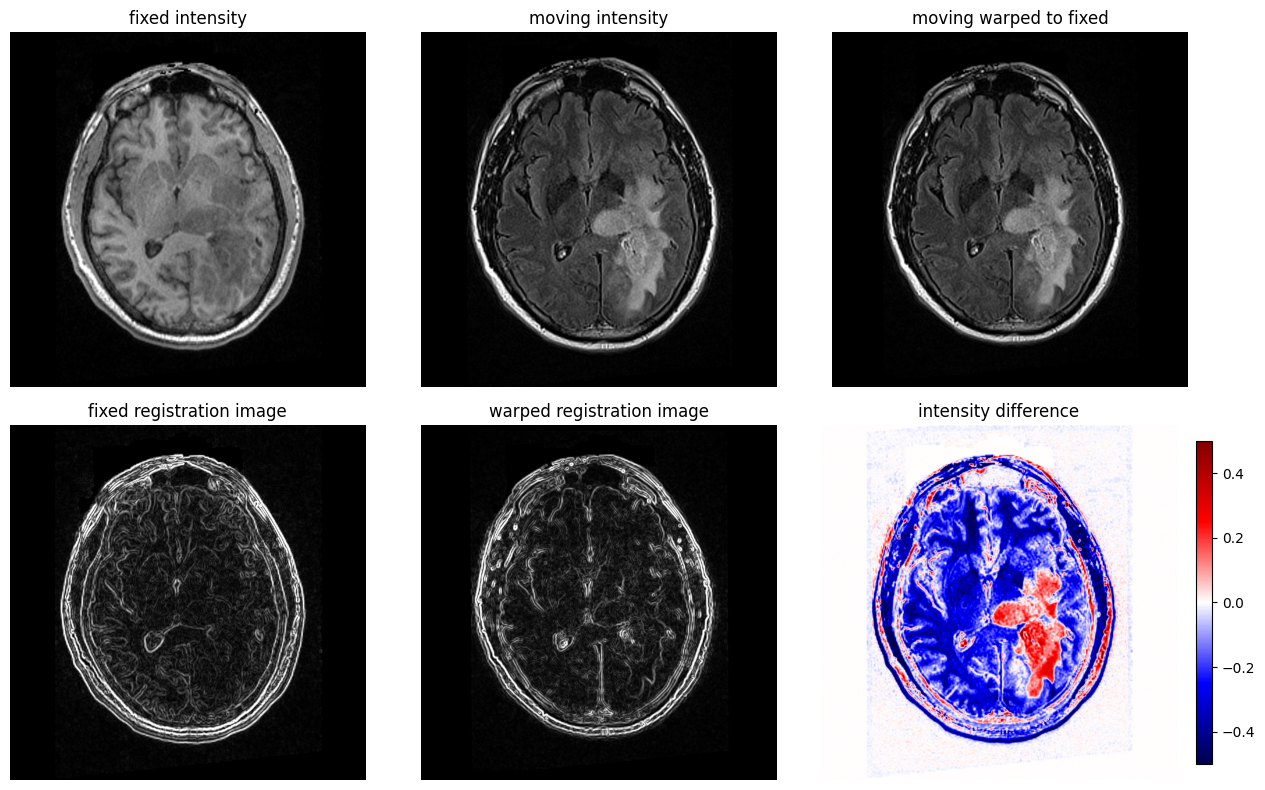

final ncc on finest registration images: 0.577236
linear part A =
[[ 1.04433253  0.00208285]
 [-0.00569561  1.03956855]]
translation: (+0.70, +4.91) mm approx


In [8]:
warped = warp(moving, final_params, MODE, output_shape=fixed.shape)
warped_reg = warp(moving_pyr[0], final_params, MODE, output_shape=fixed_pyr[0].shape)
diff = warped - fixed

fig, ax = plt.subplots(2, 3, figsize=(13, 8))
ax[0, 0].imshow(fixed, cmap='gray'); ax[0, 0].set_title('fixed intensity')
ax[0, 1].imshow(moving, cmap='gray'); ax[0, 1].set_title('moving intensity')
ax[0, 2].imshow(warped, cmap='gray'); ax[0, 2].set_title('moving warped to fixed')
ax[1, 0].imshow(fixed_pyr[0], cmap='gray'); ax[1, 0].set_title('fixed registration image')
ax[1, 1].imshow(warped_reg, cmap='gray'); ax[1, 1].set_title('warped registration image')
im = ax[1, 2].imshow(diff, cmap='seismic', vmin=-0.5, vmax=0.5)
ax[1, 2].set_title('intensity difference')
for a in ax.ravel():
    a.axis('off')
plt.colorbar(im, ax=ax[1, 2], fraction=0.04)
plt.tight_layout(); plt.show()

final_score = evaluate_metric(final_params, fixed_pyr[0], moving_pyr[0], MODE, METRIC)
print(f'final {METRIC} on finest registration images: {final_score:.6f}')

if MODE == 'rigid':
    tx, ty, theta = final_params
    print(f'translation: ({tx*PIXEL_SIZE_MM:+.2f}, {ty*PIXEL_SIZE_MM:+.2f}) mm approx')
    print(f'rotation:    {np.degrees(theta):+.3f} deg')
else:
    a11, a12, a21, a22, tx, ty = final_params
    A = np.eye(2) + np.array([[a11, a12], [a21, a22]])
    print(f'linear part A =\n{A}')
    print(f'translation: ({tx*PIXEL_SIZE_MM:+.2f}, {ty*PIXEL_SIZE_MM:+.2f}) mm approx')


## 9. Convergence check on the finest resolution

The plotted values are all re-evaluated on level 0. This is intentionally different from plotting the raw optimizer value at each pyramid level, because raw level costs are measured on different images and can hide whether the coarse-to-fine refinement is actually helping at full resolution.


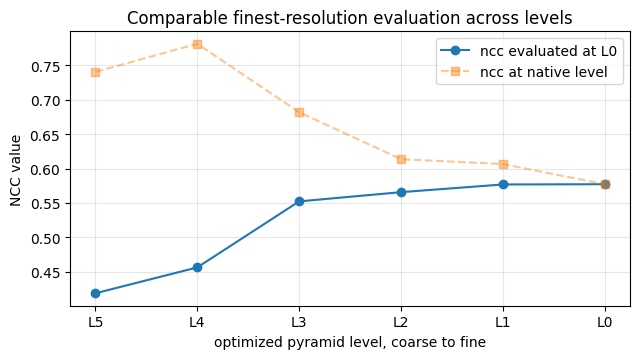

history table
level | native value | finest-resolution value
L 5   | +0.740633     | +0.418684
L 4   | +0.781428     | +0.456238
L 3   | +0.681937     | +0.552262
L 2   | +0.613647     | +0.565674
L 1   | +0.606601     | +0.576867
L 0   | +0.577236     | +0.577236


In [9]:
levels = [h['level'] for h in history]
finest_values = [h['finest_value'] for h in history]
level_values = [h['level_value'] for h in history]

plt.figure(figsize=(6.5, 3.7))
plt.plot(range(len(levels)), finest_values, 'o-', label=f'{METRIC} evaluated at L0')
plt.plot(range(len(levels)), level_values, 's--', alpha=0.45, label=f'{METRIC} at native level')
plt.xticks(range(len(levels)), [f'L{l}' for l in levels])
plt.xlabel('optimized pyramid level, coarse to fine')
plt.ylabel(f'{METRIC.upper()} value')
plt.title('Comparable finest-resolution evaluation across levels')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout(); plt.show()

print('history table')
print('level | native value | finest-resolution value')
for h in history:
    print(f"L{h['level']:>2}   | {h['level_value']:+.6f}     | {h['finest_value']:+.6f}")


## 10. Optional comparison runs

Set `RUN_EXTRA_COMPARISONS = True` to reproduce the report's rigid-vs-affine and raw-NCC-vs-gradient-NCC comparisons. It is disabled by default because the extra registrations take a few minutes.


In [11]:
RUN_EXTRA_COMPARISONS = False

if RUN_EXTRA_COMPARISONS:
    print('Rigid registration on gradient-NCC images')
    rigid_params, _ = multiscale_register(fixed_pyr, moving_pyr, 'rigid', 'ncc')
    rigid_grad_ncc = evaluate_metric(rigid_params, fixed_pyr[0], moving_pyr[0], 'rigid', 'ncc')

    print('\nAffine registration on raw-intensity NCC images')
    fixed_raw_pyr = build_registration_pyramid(fixed, N_LEVELS, 'none')
    moving_raw_pyr = build_registration_pyramid(moving, N_LEVELS, 'none')
    raw_params, _ = multiscale_register(fixed_raw_pyr, moving_raw_pyr, 'affine', 'ncc')
    raw_ncc = evaluate_metric(raw_params, fixed_raw_pyr[0], moving_raw_pyr[0], 'affine', 'ncc')
    raw_params_on_grad = evaluate_metric(raw_params, fixed_pyr[0], moving_pyr[0], 'affine', 'ncc')

    affine_grad_ncc = evaluate_metric(final_params, fixed_pyr[0], moving_pyr[0], 'affine', 'ncc')
    print('\nsummary')
    print(f'affine gradient-NCC:              {affine_grad_ncc:.6f}')
    print(f'rigid gradient-NCC:               {rigid_grad_ncc:.6f}')
    print(f'raw affine NCC on raw images:      {raw_ncc:.6f}')
    print(f'raw affine params on gradient-NCC: {raw_params_on_grad:.6f}')


## 11. Where to go from here

- **Different metrics:** NCC handles global brightness/contrast differences better than MSE, but it is still not a complete multimodal metric. Mutual information is the classic next step for harder multimodal registration.
- **Gradient preprocessing:** NCC on gradient magnitudes works well here because T1 and FLAIR share anatomical boundaries even when their raw intensities differ.
- **Transform model:** rigid registration cannot correct the mild scale/FOV mismatch between the selected T1 and FLAIR slices. Affine can model translation, rotation, shear, and scale.
- **Masks:** better anatomy masks would reduce the influence of empty borders even further.
- **Non-rigid step:** after global rigid/affine alignment, a local deformation model can handle anatomical or acquisition-related local differences.
